# ETF Return Validation Notebook

This notebook is for one-ticker validation.

Flow:
1. Review the project ticker list (reference only).
2. Set `SELECTED_TICKER` manually (can be in or outside project list).
3. Verify GBP/GBp currency.
4. Pull Yahoo history and visualize price shape.
5. Compute returns for:
   YTD, 1M, 3M, 6M, 1Y, 3Y, 5Y, 10Y, MAX, 2025, 2024, 2023, 2022.

Returned metrics:
- `open_price_return_pct`
- `market_price_return_pct` (Close)


In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from fetch_etf_prices import ETF_LABEL_TO_TICKER

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)


In [2]:
ALLOWED_CCY = {"GBP", "GBp"}

options_df = pd.DataFrame(
    [{"label": label, "ticker": ticker} for label, ticker in ETF_LABEL_TO_TICKER.items()]
).sort_values(["label", "ticker"]).reset_index(drop=True)

# Step 1: project ticker reference list.
options_df

# Step 2: manual selection (can be custom ticker not in options_df).
SELECTED_TICKER = "SAUS.L"  # <- change and rerun this cell

match = options_df.loc[options_df["ticker"] == SELECTED_TICKER, "label"]
selected_label = match.iloc[0] if not match.empty else "(Custom ticker, not in project list)"

info = yf.Ticker(SELECTED_TICKER).info
selected_currency = info.get("currency")
selected_exchange = info.get("exchange")
selected_quote_type = info.get("quoteType")

print(f"Selected ETF: {selected_label} / {SELECTED_TICKER}")
print(f"Exchange: {selected_exchange} | Currency: {selected_currency} | Quote Type: {selected_quote_type}")

if selected_currency not in ALLOWED_CCY:
    print("This ticker is not GBP/GBp. Pick another ticker and rerun this cell.")
else:
    print("Currency check passed (GBP/GBp). Continue.")


Selected ETF: Australia / SAUS.L
Exchange: LSE | Currency: GBp | Quote Type: ETF
Currency check passed (GBP/GBp). Continue.


In [3]:
hist = yf.Ticker(SELECTED_TICKER).history(period="max", auto_adjust=False, actions=True).copy()
hist = hist.sort_index()
if getattr(hist.index, "tz", None) is not None:
    hist.index = hist.index.tz_localize(None)

if hist.empty:
    raise RuntimeError("No history returned for selected ticker. Choose another ticker.")

scale = 0.01 if selected_currency == "GBp" else 1.0
hist["Open_GBP"] = hist["Open"] * scale
hist["Close_GBP"] = hist["Close"] * scale

cols = [
    "Open", "High", "Low", "Close",
    "Open_GBP", "Close_GBP",
    "Dividends", "Stock Splits",
]

preview_head = hist[cols].head(5).copy()
preview_head.insert(0, "__section", "HEAD")
preview_tail = hist[cols].tail(5).copy()
preview_tail.insert(0, "__section", "TAIL")
pd.concat([preview_head, preview_tail])


,__section,Open,High,Low,Close,Open_GBP,Close_GBP,Dividends,Stock Splits
Date,,,,,,,,,
2010-01-22,HEAD,2426.687012,2426.687012,2426.687012,2426.687012,24.26687,24.26687,0.0,0.0
2010-01-25,HEAD,1467.459961,1467.459961,1467.459961,1467.459961,14.67460,14.67460,0.0,0.0
2010-01-26,HEAD,1465.489990,1465.489990,1465.489990,1465.489990,14.65490,14.65490,0.0,0.0
2010-01-27,HEAD,1434.229980,1434.229980,1434.229980,1434.229980,14.34230,14.34230,0.0,0.0
2010-01-28,HEAD,1432.729980,1432.729980,1432.729980,1432.729980,14.32730,14.32730,0.0,0.0
2026-02-24,TAIL,4667.000000,4687.000000,4659.000000,4683.000000,46.67000,46.83000,0.0,0.0
2026-02-25,TAIL,4748.000000,4771.000000,4727.919922,4767.000000,47.48000,47.67000,0.0,0.0
2026-02-26,TAIL,4779.000000,4779.000000,4738.000000,4765.500000,47.79000,47.65500,0.0,0.0
2026-02-27,TAIL,4811.000000,4825.000000,4782.000000,4803.000000,48.11000,48.03000,0.0,0.0


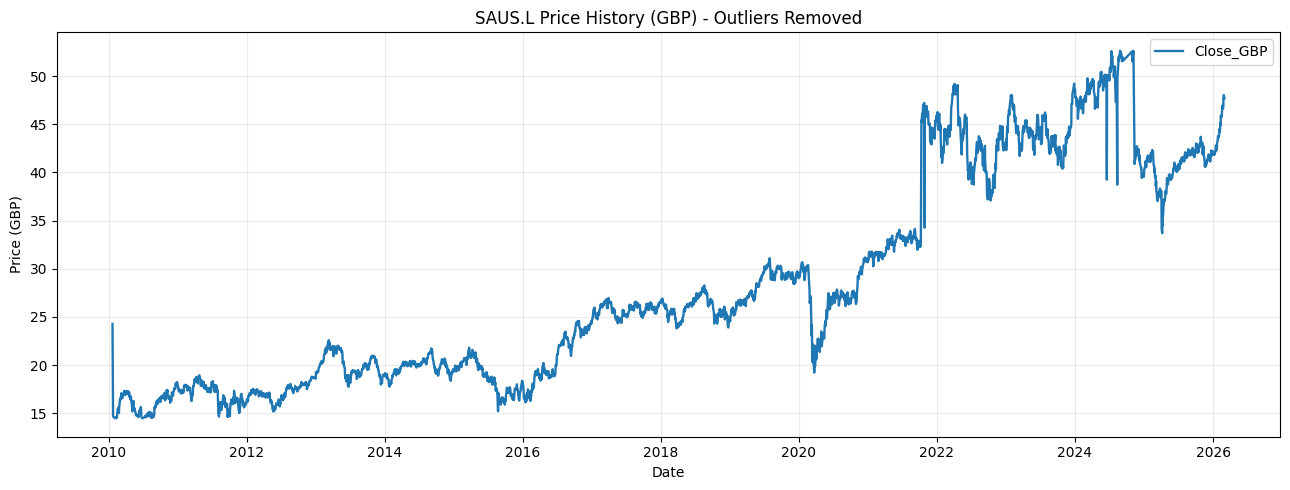

No extreme one-day break markers detected with threshold <0.2x or >5.0x.


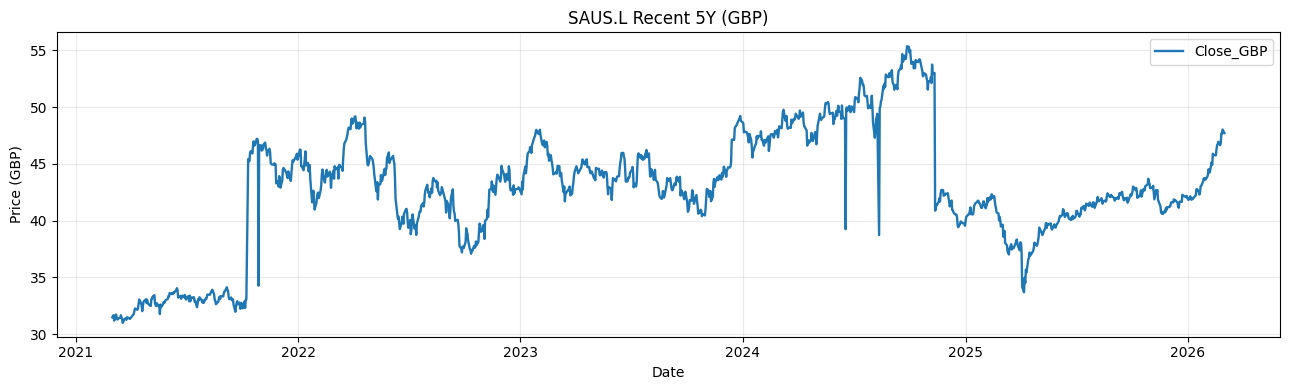

In [4]:
# Visual diagnostics
plot_df = hist[["Close_GBP"]].dropna(how="any").copy()
# Graph 1: remove outliers (1st-99th percentile filter on Close_GBP)
q_low = plot_df["Close_GBP"].quantile(0.01)
q_high = plot_df["Close_GBP"].quantile(0.99)
plot_df_filtered = plot_df[(plot_df["Close_GBP"] >= q_low) & (plot_df["Close_GBP"] <= q_high)]
ratio = (plot_df["Close_GBP"] / plot_df["Close_GBP"].shift(1)).dropna()
break_points = ratio[(ratio < 0.2) | (ratio > 5.0)].index
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(plot_df_filtered.index, plot_df_filtered["Close_GBP"], label="Close_GBP", linewidth=1.7)
for dt in break_points:
    if dt in plot_df_filtered.index:
        ax.axvline(dt, color="red", linestyle="--", alpha=0.35, linewidth=1)
ax.set_title(f"{SELECTED_TICKER} Price History (GBP) - Outliers Removed")
ax.set_xlabel("Date")
ax.set_ylabel("Price (GBP)")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
if len(break_points) == 0:
    print("No extreme one-day break markers detected with threshold <0.2x or >5.0x.")
else:
    print("Potential break dates:")
    print(pd.Series(break_points).dt.date.to_string(index=False))
# Graph 2: recent 5Y view (Close and Open only)
zoom_years = 5
zoom_start = plot_df.index.max() - pd.DateOffset(years=zoom_years)
zoom_df = plot_df.loc[plot_df.index >= zoom_start]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(zoom_df.index, zoom_df["Close_GBP"], label="Close_GBP", linewidth=1.7)
ax.set_title(f"{SELECTED_TICKER} Recent {zoom_years}Y (GBP)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (GBP)")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [5]:
end_date = pd.Timestamp(hist.index.max())

open_s = hist["Open_GBP"].copy()
close_s = hist["Close_GBP"].copy()
div_s = hist["Dividends"].fillna(0).copy() if "Dividends" in hist.columns else pd.Series(0, index=hist.index)
split_s = hist["Stock Splits"].fillna(0).copy() if "Stock Splits" in hist.columns else pd.Series(0, index=hist.index)


def _last_on_or_before_local(series: pd.Series, target: pd.Timestamp):
    s = series.dropna()
    t = pd.Timestamp(target)
    s = s[s.index <= t]
    if s.empty:
        return None, None
    idx = s.index[-1]
    return idx, float(s.loc[idx])


def _first_in_year_local(series: pd.Series, year: int):
    s = series.dropna()
    s = s[s.index.year == year]
    if s.empty:
        return None, None
    idx = s.index[0]
    return idx, float(s.iloc[0])


def _last_in_year_local(series: pd.Series, year: int):
    s = series.dropna()
    s = s[s.index.year == year]
    if s.empty:
        return None, None
    idx = s.index[-1]
    return idx, float(s.iloc[-1])


def _pct_return_local(start_value: float, end_value: float) -> float:
    return ((end_value / start_value) - 1.0) * 100.0


# Detect suspicious one-day level shifts not explained by splits/dividends.
ratio = (close_s / close_s.shift(1)).dropna()
suspicious = ratio[(ratio < 0.2) | (ratio > 5.0)]
if not suspicious.empty:
    safe_breaks = []
    for dt in suspicious.index:
        if float(split_s.get(dt, 0.0)) == 0.0 and float(div_s.get(dt, 0.0)) == 0.0:
            safe_breaks.append(dt)
    stable_start_override = min(safe_breaks) if safe_breaks else None
else:
    stable_start_override = None

periods = [
    ("YTD", "ytd"),
    ("1 Month", pd.DateOffset(months=1)),
    ("3 Months", pd.DateOffset(months=3)),
    ("6 Months", pd.DateOffset(months=6)),
    ("1 Year", pd.DateOffset(years=1)),
    ("3 Years", pd.DateOffset(years=3)),
    ("5 Years", pd.DateOffset(years=5)),
    ("10 Years", pd.DateOffset(years=10)),
    ("MAX", "max"),
]

rows = []

for label, spec in periods:
    if spec == "max":
        common_idx = open_s.dropna().index.intersection(close_s.dropna().index)
        if common_idx.empty:
            continue

        min_start = common_idx.min()
        if stable_start_override is not None and stable_start_override > min_start:
            min_start = stable_start_override

        eligible_idx = common_idx[common_idx >= min_start]
        if len(eligible_idx) >= 2:
            start_idx = eligible_idx[1]  # use 2nd day to avoid noisy first print
        else:
            start_idx = eligible_idx[0]

        start_open = float(open_s.loc[start_idx])
        start_close = float(close_s.loc[start_idx])

        end_open = float(open_s.dropna().iloc[-1])
        end_close = float(close_s.dropna().iloc[-1])

    elif spec == "ytd":
        jan1 = pd.Timestamp(year=end_date.year, month=1, day=1)
        start_idx, start_open = _last_on_or_before_local(open_s, jan1)
        _, start_close = _last_on_or_before_local(close_s, jan1)

        _, end_open = _last_on_or_before_local(open_s, end_date)
        _, end_close = _last_on_or_before_local(close_s, end_date)

    else:
        target = end_date - spec
        start_idx, start_open = _last_on_or_before_local(open_s, target)
        _, start_close = _last_on_or_before_local(close_s, target)

        _, end_open = _last_on_or_before_local(open_s, end_date)
        _, end_close = _last_on_or_before_local(close_s, end_date)

    if None in {start_open, start_close, end_open, end_close}:
        continue

    rows.append(
        {
            "period": label,
            "start_date": pd.Timestamp(start_idx).date(),
            "end_date": pd.Timestamp(end_date).date(),
            "open_price_return_pct": _pct_return_local(start_open, end_open),
            "market_price_return_pct": _pct_return_local(start_close, end_close),
        }
    )

for y in [2025, 2024, 2023, 2022]:
    sidx_open, s_open = _first_in_year_local(open_s, y)
    eidx_open, e_open = _last_in_year_local(open_s, y)
    sidx_close, s_close = _first_in_year_local(close_s, y)
    eidx_close, e_close = _last_in_year_local(close_s, y)

    if None in {s_open, e_open, s_close, e_close}:
        continue

    rows.append(
        {
            "period": str(y),
            "start_date": pd.Timestamp(sidx_close).date(),
            "end_date": pd.Timestamp(eidx_close).date(),
            "open_price_return_pct": _pct_return_local(s_open, e_open),
            "market_price_return_pct": _pct_return_local(s_close, e_close),
        }
    )

returns_df = pd.DataFrame(rows)
period_order = ["YTD", "1 Month", "3 Months", "6 Months", "1 Year", "3 Years", "5 Years", "10 Years", "MAX", "2025", "2024", "2023", "2022"]
returns_df["period"] = pd.Categorical(returns_df["period"], categories=period_order, ordered=True)
returns_df = returns_df.sort_values("period").reset_index(drop=True)

print(f"Selected ETF: {selected_label} / {SELECTED_TICKER}")
print(f"Exchange: {selected_exchange}, Currency in Yahoo: {selected_currency}, GBP scale factor applied: {scale}")
if stable_start_override is not None:
    print(f"Warning: detected unexplained level break in Yahoo history. MAX starts from {stable_start_override.date()}.")

returns_df


Selected ETF: Australia / SAUS.L
Exchange: LSE, Currency in Yahoo: GBp, GBP scale factor applied: 0.01


,period,start_date,end_date,open_price_return_pct,market_price_return_pct
0,YTD,2025-12-31,2026-03-02,13.871044,13.568198
1,1 Month,2026-02-02,2026-03-02,10.658960,8.740741
2,3 Months,2025-12-02,2026-03-02,16.024242,15.618563
3,6 Months,2025-09-02,2026-03-02,13.898144,13.649357
4,1 Year,2025-02-28,2026-03-02,21.472081,20.830695
5,3 Years,2023-03-02,2026-03-02,8.599955,8.075660
6,5 Years,2021-03-02,2026-03-02,52.323361,51.532476
7,10 Years,2016-03-02,2026-03-02,160.462585,159.787640
8,MAX,2010-01-25,2026-03-02,226.141777,225.119603
9,2025,2025-01-02,2025-12-31,5.470514,4.217316
